# **All Life Bank Personal Loan Campaign**

## **Identifying and Predicting Potential Loan Consumers**

### Northern Arizona University - The W.A. Franke College of Business

#### Cole T. Catron, Ella Buxton, Xuanzhong Chen, & Rohit A. Gonthina
---

### **Data Dictionary**

* ***ID:*** Unique identifier for each customer.
* ***Age:*** Age of the customer in complete years.
* ***Experience:*** Number of years of professional work experience.
* ***Income:*** Annual income of the customer, measured in thousands of dollars.
* ***ZIPCode:*** ZIP code of the customer’s home address.
* ***Family:*** Number of immediate family members in the customer’s household.
* ***CCAvg:*** Average monthly spending on credit cards, expressed in thousands of dollars.
* ***Education:*** Highest level of education attained by the customer, categorized as:
   - 1: Undergraduate degree
   - 2: Graduate degree
   - 3: Advanced/Professional degree
* ***Mortgage:*** Outstanding mortgage value on the customer’s house, expressed in thousands of dollars.  
* ***Personal_Loan:*** Indicates whether the customer accepted a personal loan offer during the last campaign (0 = No; 1 = Yes).
* ***Securities_Account:*** Indicates whether the customer holds a securities account with All Life Bank (0 = No; 1 = Yes).
* ***CD_Account:*** Indicates whether the customer holds a certificate of deposit (CD) account with All Life Bank (0 = No; 1 = Yes).
* ***Online:*** Indicates whether the customer uses internet banking services (0 = No; 1 = Yes).
* ***CreditCard:*** Indicates whether the customer uses a credit card issued by a bank other than All Life Bank (0 = No; 1 = Yes).

### **Loading Data and Main Libraries**

In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import data
df = pd.read_csv('/content/Loan_Modelling.csv')

# Header
print("Header:\n")
print(df.head())

Header:

   ID  Age  Experience  Income  ZIPCode  Family  CCAvg  Education  Mortgage  \
0   1   25           1      49    91107       4    1.6          1         0   
1   2   45          19      34    90089       3    1.5          1         0   
2   3   39          15      11    94720       1    1.0          1         0   
3   4   35           9     100    94112       1    2.7          2         0   
4   5   35           8      45    91330       4    1.0          2         0   

   Personal_Loan  Securities_Account  CD_Account  Online  CreditCard  
0              0                   1           0       0           0  
1              0                   1           0       0           0  
2              0                   0           0       0           0  
3              0                   0           0       0           0  
4              0                   0           0       0           1  


### **Initial Descriptive Statistics and Data Frame Analysis**

The dataset comprises information on $5,000$ depositors who currently utilize services and financial products offered by All Life Bank. The bank aims to expand its loan portfolio by converting these depositors into loan customers while retaining their business as depositors. The attributes included in the model capture a range of factors, including demographic and economic characteristics, spending behaviors, residential location, and existing usage of the bank’s services.

Upon assessing the dataset for null values, no missing data was identified. However, during the initial descriptive analysis, anomalies were detected in the Experience variable, where negative values were present. As negative years of experience are not logically consistent with real-world work history, these records (a total of $52$ observations) were removed through a filtering process, retaining only values where Experience was greater than or equal to zero.

Following this adjustment, a subsequent descriptive analysis was conducted. It revealed that the median and mean values for Experience and Age were closely aligned. In contrast, other quantitative features exhibited noticeable skewness. Specifically, the variables *Income*, *CCAvg*, and *Mortgage* showed potential outliers with high extreme values, likely reflective of All Life Bank's focus on higher-income customers and those with substantial credit card spending and mortgage balances—typical attributes of individuals capable of repaying loans.

Further analysis highlighted key customer demographics and behaviors:

* Only $9.6$% of the sample had taken a personal loan during the campaign.
* $29.4$% of customers owned a credit card issued by the bank.
* $59.7$% of customers used online banking services.
* Customers with certificates of deposit (CD) accounts made up $6.1$%, while those holding securities accounts accounted for $10.4$%.

These statistics suggest that All Life Bank’s customer base utilizes a diverse range of services and products. It is also possible that many customers engage with multiple offerings, contributing to their overall financial relationship with the bank.

In [ ]:
# Descriptive statistics
print("\nDescriptive Statistics:\n")
print(df.describe())
print()

# Check for nulls
print("Nulls:\n")
print(df.isnull().sum())

# Filter data to only include minimum 'Experience' to 0 or above
df = df[df['Experience'] >= 0]
print("\nFiltered Data:\n")
print(df.head())

# New descriptive statistics
print("\nNew Descriptive Statistics:\n")
print(df.describe())


Descriptive Statistics:

                ID          Age   Experience       Income       ZIPCode  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean   2500.500000    45.338400    20.104600    73.774200  93169.257000   
std    1443.520003    11.463166    11.467954    46.033729   1759.455086   
min       1.000000    23.000000    -3.000000     8.000000  90005.000000   
25%    1250.750000    35.000000    10.000000    39.000000  91911.000000   
50%    2500.500000    45.000000    20.000000    64.000000  93437.000000   
75%    3750.250000    55.000000    30.000000    98.000000  94608.000000   
max    5000.000000    67.000000    43.000000   224.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal_Loan  \
count  5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean      2.396400     1.937938     1.881000    56.498800       0.096000   
std       1.147663     1.747659     0.839869   101.713802       0.2946

### **Using Histograms to Visualize Distributions of Quantitative Variables**

The distributions of key quantitative variables (*Age*, *Experience*, *Income*, *Family*, *CCAvg*, and *Mortgage*) were visualized through histograms to gain insights into customer characteristics. The analysis revealed the following notable patterns:

* The variables *Income*, *CCAvg* (average monthly credit card spending), and *Mortgage* each exhibited a significant presence of outliers. These extreme values highlight the diversity within AllLife Bank’s customer base and may represent unique segments that are worth conducting further analysis.

* The *Mortgage* variable is unique, with a median value of zero. This could tell the story that many AllLife customers either do not hold a mortgage or have fully paid it off. Consequently, outstanding mortgage balances may not serve as a meaningful predictor of personal loan acceptance from the bank's campaigns. This insight may help the bank refine its campaign targeting to focus on other, more representative features.

* The majority of depositors have a family size of 1, as indicated by the *Family* variable. This demographic detail could influence loan acceptance rates, as single households may exhibit different borrowing behaviors in comparison to larger households.

* Most of AllLife's depositors report low average monthly credit card spending amounts as demonstrated by the *CCAvg* feature. This suggests that the bank’s customer base is generally conservative in its credit card spending behaviors, which may influence their propensity to take out loans.

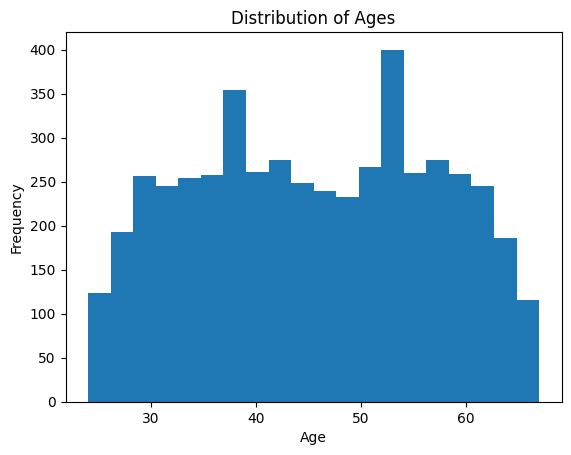

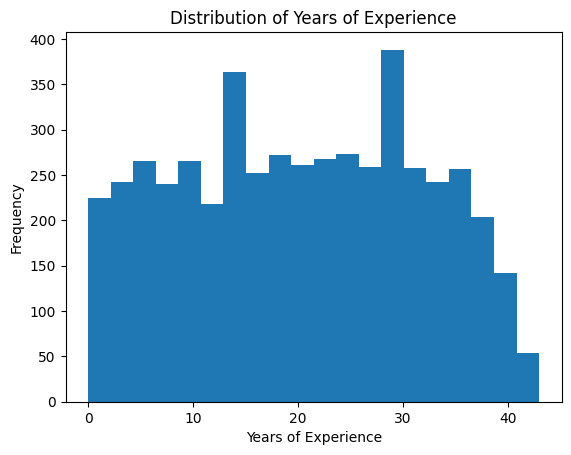

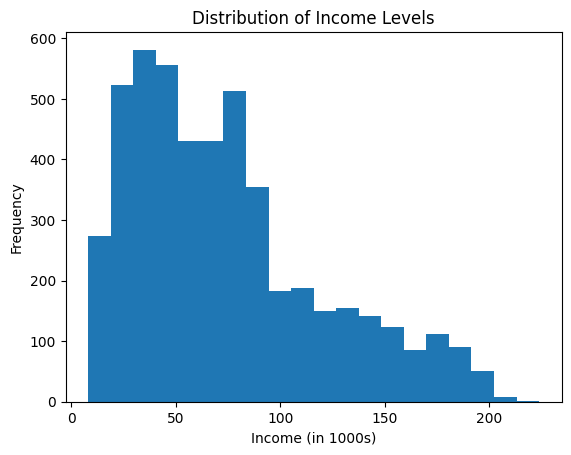

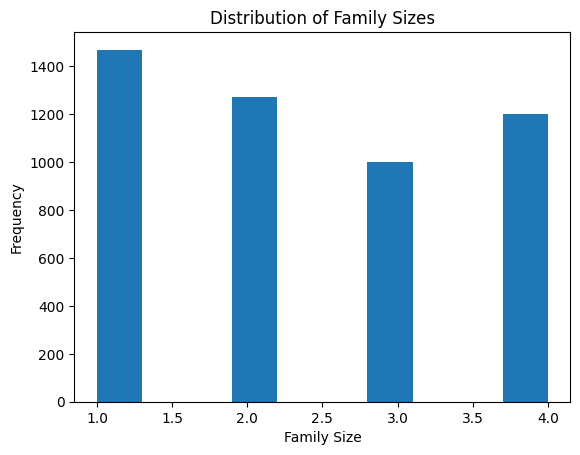

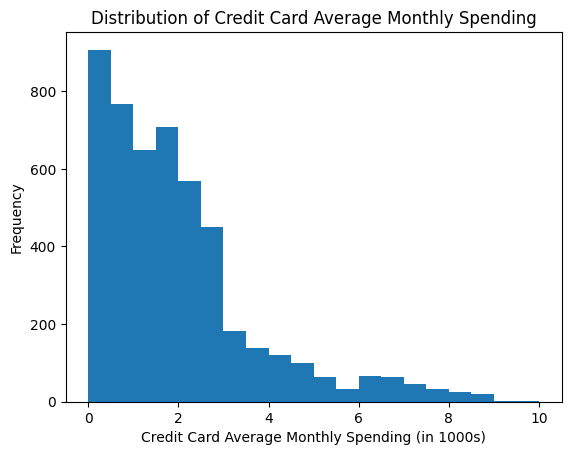

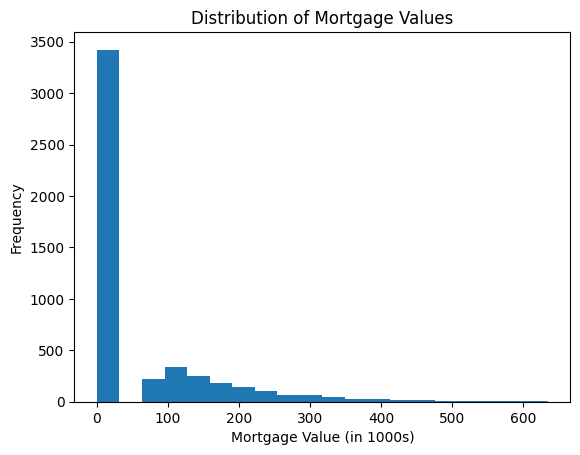

In [ ]:
# 'Age' histogram
plt.hist(df['Age'], bins=20)
plt.title('Distribution of Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 'Experience' histogram
plt.hist(df['Experience'], bins=20)
plt.title('Distribution of Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Frequency')
plt.show()

# 'Income' histogram
plt.hist(df['Income'], bins=20)
plt.title('Distribution of Income Levels')
plt.xlabel('Income (in 1000s)')
plt.ylabel('Frequency')
plt.show()

# 'Family' histogram
plt.hist(df['Family'], bins=10)
plt.title('Distribution of Family Sizes')
plt.xlabel('Family Size')
plt.ylabel('Frequency')
plt.show()

# 'CCAvg' histogram
plt.hist(df['CCAvg'], bins=20)
plt.title('Distribution of Credit Card Average Monthly Spending')
plt.xlabel('Credit Card Average Monthly Spending (in 1000s)')
plt.ylabel('Frequency')
plt.show()

# 'Mortgage' histogram
plt.hist(df['Mortgage'], bins=20)
plt.title('Distribution of Mortgage Values')
plt.xlabel('Mortgage Value (in 1000s)')
plt.ylabel('Frequency')
plt.show()

### **Treatment of Outliers, Final Data Cleaning, and New Descriptive Statistics**

After analyzing the descriptive statistics and visualizing the data via histograms, extreme values were identified in the attributes *Income*, *CCAvg* (average monthly credit card spending), and *Mortgage*, which significantly skewed their distributions. To address this, outliers were removed, resulting in distributions where median and mean values aligned more closely. While these variables continue to exhibit some skewness and retain outliers, the number of extreme cases has been greatly reduced. The number of observations in the data decreased by $13.3$% to a data set size that now holds $4,333$ customers.

Following this data cleansing, key characteristics and behaviors of AllLife Bank's updated customer base are as follows:

* $6.2$% of AllLife Bank's customers accepted a personal loan offer from their last campaign.
* $29.6$% of customers use a credit card not issued by AllLife Bank.
* $59.3$% of customers utilize online banking services.
* $4.8$% of customers have a certificate of deposit (CD) account.
* $10.4$% of customers hold a securities account, which did not change since the initial descriptive analysis.
* Demographic insights show that the typical customer age is 46 years and possess 21 years of professional experience.
* Financial and economic characteristics show that a customer typically has a median annual income of $58,000$, a monthly credit card spending amount of $1,400$ and a median mortgage value of $0$ despite the average being $37,600$.
* Many customers likely do not hold a mortgage or have fully paid it off, resulting in a right-skewed distribution.

In [ ]:
# Remove outliers for 'Income'
Q1_income = df['Income'].quantile(0.25)
Q3_income = df['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
df = df[(df['Income'] >= Q1_income - 1.5 * IQR_income) & (df['Income'] <= Q3_income + 1.5 * IQR_income)]

# Remove outliers for 'CCAvg'
Q1_ccavg = df['CCAvg'].quantile(0.25)
Q3_ccavg = df['CCAvg'].quantile(0.75)
IQR_ccavg = Q3_ccavg - Q1_ccavg
df = df[(df['CCAvg'] >= Q1_ccavg - 1.5 * IQR_ccavg) & (df['CCAvg'] <= Q3_ccavg + 1.5 * IQR_ccavg)]

# Remove outliers for 'Mortgage'
Q1_mortgage = df['Mortgage'].quantile(0.25)
Q3_mortgage = df['Mortgage'].quantile(0.75)
IQR_mortgage = Q3_mortgage - Q1_mortgage
df = df[(df['Mortgage'] >= Q1_mortgage - 1.5 * IQR_mortgage) & (df['Mortgage'] <= Q3_mortgage + 1.5 * IQR_mortgage)]

# New descriptive statistics
print("\nNew Descriptive Statistics:\n")
print(df.describe())

# Assign the categories for the 'Education' attribute
education_categories = {
    1: 'Undergraduate',
    2: 'Graduate',
    3: 'Advanced/Professional'
}

# Apply mapping to the 'Education' column
df['Education'] = df['Education'].map(education_categories)

# Save data file
df.to_csv('cleaned_loan_data.csv', index=False)


New Descriptive Statistics:

                ID          Age   Experience       Income       ZIPCode  \
count  4333.000000  4333.000000  4333.000000  4333.000000   4333.000000   
mean   2511.542580    45.762520    20.514655    63.987307  93175.140549   
std    1446.150116    11.351948    11.359121    38.058680   1762.304805   
min       1.000000    24.000000     0.000000     8.000000  90005.000000   
25%    1258.000000    36.000000    11.000000    35.000000  91941.000000   
50%    2512.000000    46.000000    21.000000    58.000000  93524.000000   
75%    3765.000000    56.000000    30.000000    83.000000  94608.000000   
max    5000.000000    67.000000    43.000000   185.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal_Loan  \
count  4333.000000  4333.000000  4333.000000  4333.000000    4333.000000   
mean      2.436880     1.547674     1.919686    37.593584       0.062312   
std       1.161278     1.157854     0.835507    66.721333       0.

### **Exploratory Data Analysis**

Three plots were created to examine how the acceptance of personal loans from AllLife Bank’s previous campaign varied across customer characteristics, for instance, education levels, median income, and median monthly credit card spending. Additionally, a heatmap was used to analyze correlations among quantitative variables. Categorical variables such as *Education* and *ZIPCode* were excluded, as their numerical representations do not indicate meaningful relationships. The *ID* variable, being a unique identifier, was also excluded from the analysis.

The first plot illustrates the proportion of loan acceptance across education levels, which derived the following insights:

* Customers with an undergraduate education had the lowest acceptance rate, with only $2.9$% accepting a loan.
* Graduate-educated customers exhibited the highest acceptance rate at $8.4$%, suggesting that higher education levels possibly correlate with increased loan acceptance, potentially due to greater financial literacy or stability.

The second plot compares the median incomes of customers who accepted loans versus those who did not, revealing the subsequent information:

* The median income for those who accepted a loan was $131,000$, compared to $53,000$ for those who did not. This suggests that higher-income customers are more likely to accept loans, likely due to greater repayment capacity.

The third plot examines the differences in monthly credit card spending:

* Customers who accepted loans had a median monthly credit card spending of $3,200$, compared to $1,300$ for those who did not.
This indicates that higher spending habits may align with credit-seeking behaviors, making such customers more inclined to accept personal loans.

Lastly, a heatmap was utilized to visualize correlations between quantitative and binary variables. Key observations are listed below:

* *Age* and *Experience* have a near-perfect correlation ($0.99$), as work experience naturally increases with age. For predictive modeling, only one of these variables should be included to avoid multicollinearity.

* The two relationships *CCAvg* and *Income* ($0.52$) and *CD_Account* and *Securities_Account* ($0.32$) show moderate-to-strong correlations.

* *Income* ($0.52$) and *CCAvg* ($0.47$) showed the strongest correlations with Personal_Loan. This may demonstrate that higher incomes may increase loan acceptance rates, as financial stability and repayment capacity are crucial factors. Elevated credit card spending could also signal a propensity for borrowing, making these customers more likely to take out loans, as evidenced by the following plots.

In [ ]:
# Average 'Personal_Loan' by Education
education_loan_counts = df.groupby('Education')['Personal_Loan'].value_counts().unstack().fillna(0)
print(education_loan_counts)
print()

# Median 'Income' by 'Personal_Loan'
income_loan_counts = df.groupby('Personal_Loan')['Income'].median()
print(income_loan_counts)
print()

# 'Median 'CCAvg' by 'Personal_Loan'
ccavg_loan_counts = df.groupby('Personal_Loan')['CCAvg'].median()
print(ccavg_loan_counts)
print()

Personal_Loan             0    1
Education                       
Advanced/Professional  1240  112
Graduate               1173  108
Undergraduate          1650   50

Personal_Loan
0     53.0
1    131.0
Name: Income, dtype: float64

Personal_Loan
0    1.3
1    3.2
Name: CCAvg, dtype: float64



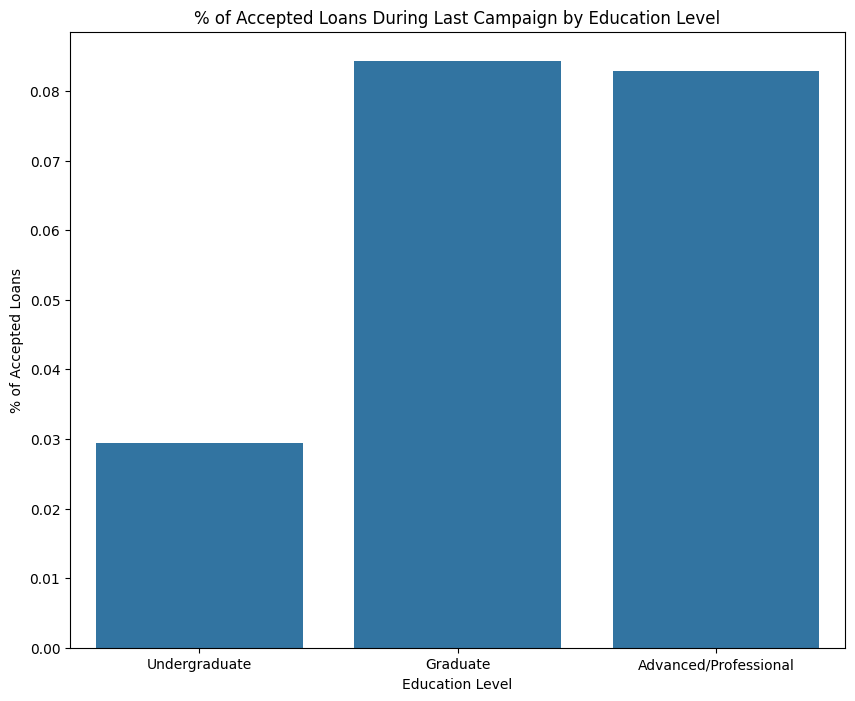

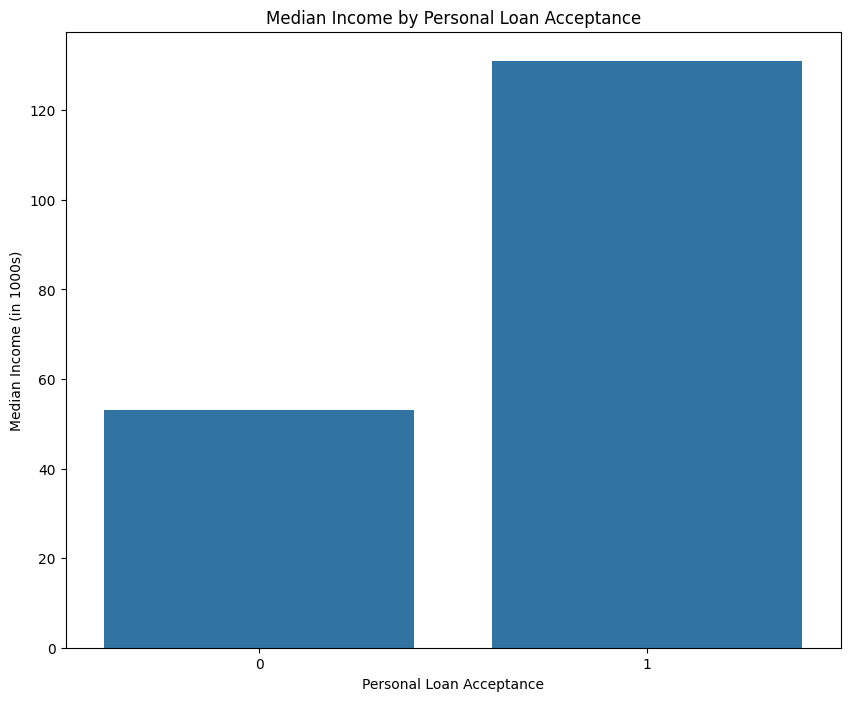

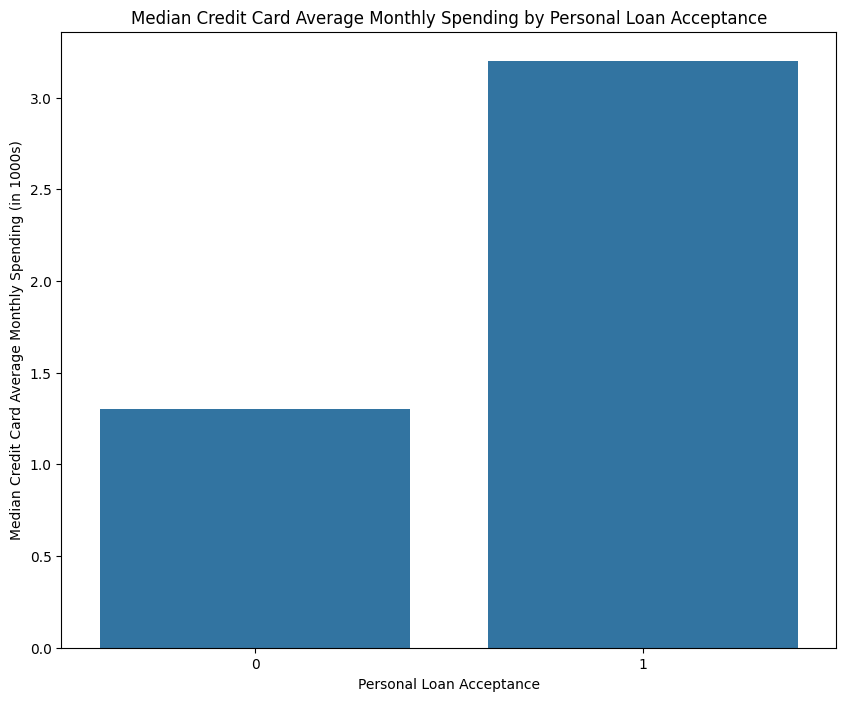

In [ ]:
# Visualize Average 'Personal_Loan' by 'Education'
plt.figure(figsize=(10, 8))
sns.barplot(x='Education', y='Personal_Loan', data=df, errorbar=None)
plt.title('% of Accepted Loans During Last Campaign by Education Level')
plt.xlabel('Education Level')
plt.ylabel('% of Accepted Loans')
plt.show()

# Visualize comparison of 'Personal_Loan' by Median 'Income'
plt.figure(figsize=(10, 8))
sns.barplot(x='Personal_Loan', y='Income', data=df, errorbar=None,
            estimator=np.median)
plt.title('Median Income by Personal Loan Acceptance')
plt.xlabel('Personal Loan Acceptance')
plt.ylabel('Median Income (in 1000s)')
plt.show()

# Visualize comparison of 'Personal Loan' by Median 'CCAvg'
plt.figure(figsize=(10, 8))
sns.barplot(x='Personal_Loan', y='CCAvg', data=df, errorbar=None,
            estimator=np.median)
plt.title('Median Credit Card Average Monthly Spending by Personal Loan Acceptance')
plt.xlabel('Personal Loan Acceptance')
plt.ylabel('Median Credit Card Average Monthly Spending (in 1000s)')
plt.show()

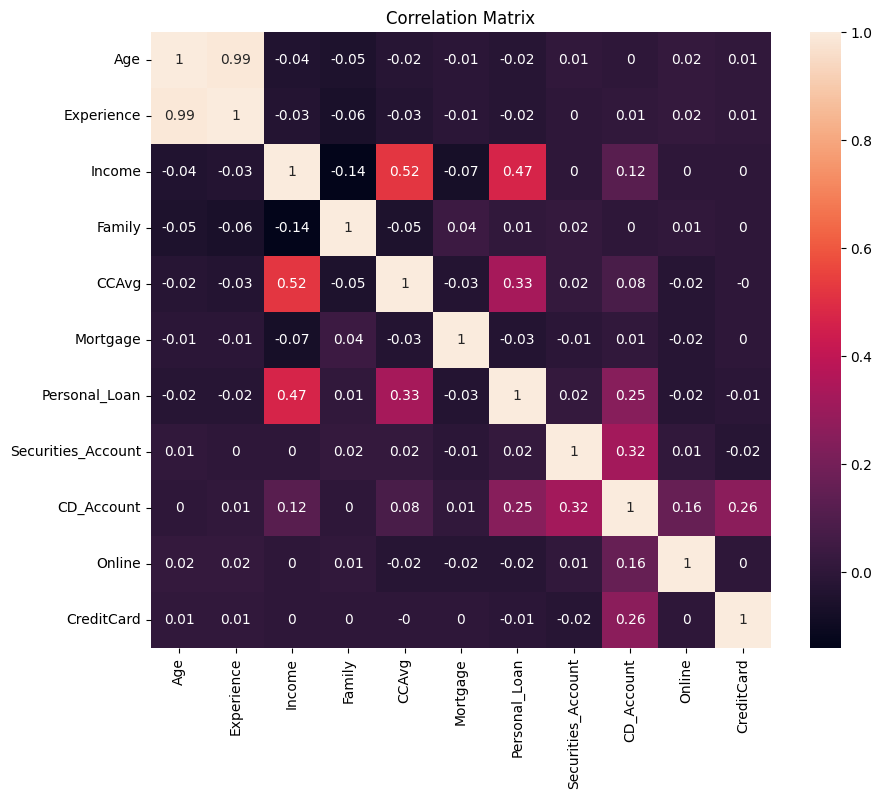

In [ ]:
# Subset dataset to remove 'Education', 'ZipCode', and 'ID' features
df_subset = df.drop(['Education', 'ZIPCode', 'ID'], axis=1)

# Correlation Matrix
correlation_matrix = df_subset.corr()
correlation_matrix = correlation_matrix.round(2)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.show()

### **Logistic Regression Model**

Through applying the logistic regression technique to predict whether a customer accepts a loan, the following coefficients and their interpretations are listed below:

*   ***Income:*** An increase in a customer's income by $1,000$ (a value of 1) is equated to an increase in the odds of a customer taking a loan by a factor of $1.07$.
*   ***Family:*** An increase in a customer's family size by 1 member equates to an increase in the odds of a customer taking a loan by a factor of $1.67$.
*   ***CCAvg:*** An increase in a customer's average monthly credit card spending by $1,000$ (a value of 1) is equated to an increase in the odds of a customer taking a loan by a factor of $2.04$.
*   ***Securities_Account:*** An active securities account with the bank equates to a decrease in the odds of that customer taking a loan by a factor of $0.36$.
*   ***CD_Account:*** An active CD account with the bank equates to a increase in the odds of that customer taking a loan by a factor of $46.11$.
*   ***Online:*** The presence of a customer who utilizes online banking services equates to a decrease in the odds of that customer taking a loan by a factor of $0.51$.
*   ***CreditCard:*** The presence of a customer who has a credit card with an external bank equates to a decrease in the odds of that customer taking a loan by a factor of $0.31$.
*   ***Graduate_Degree:*** The presence of a customer who has a graduate-level degree equates to an increase in the odds of that customer taking a loan by a factor of $26.39$ compared to those with an undergraduate degree.
*   ***Advanced_Professional:*** The presence of a customer who has an advanced or professional degree equates to an increase in the odds of that customer taking a loan by a factor of $23.34$ compared to those with an undergraduate degree.

**Positive Impacts on Odds of Loan Acceptance**

Based on the analysis of AllLife Bank's last personal loan campaign, the presence of a certificate of deposit (CD) account and higher levels of education had the most positive impacts on the likelihood of customers accepting loans.

* Customers with CD accounts may have reduced liquidity compared to those without, making them more likely to see a loan as a solution for short-term financial needs.
* Higher education levels correlate with increased familiarity and experience with financial products, including loans, which likely translates to greater confidence in managing these key acceptance decisions.

While income also positively affects the odds of loan acceptance, its influence is less impactful compared to CD ownership and education levels. This suggests that while income is an important factor in loan decision-making, it may not outweigh the factors associated with education and liquidity.

**Negative Impacts on Odds of Loan Acceptance**

The variables most negatively associated with loan acceptance include online banking usage, ownership of active securities accounts, and having a credit card with an external bank.

* Customers using online banking services offered by AllLife Bank had the greatest reduction in loan acceptance odds. This may stem from perceptions of loan offers as predatory or aggressive in nature, potentially raising concerns about the bank's authenticity. Additionally, online banking users may have higher financial literacy or education, enabling them to critically evaluate and decline less favorable loan terms.
* Customers with securities accounts might rely on their investment holdings as a financial safety net, reducing the perceived need for personal loans. These accounts can provide liquidity through future sales of investment holdings, minimizing the appeal of borrowing to these investors.
* Customers with credit cards issued by other banks may already have access to sufficient credit, making the offered loans less attractive. This behavior may also reflect debt aversion, where individuals are cautious about taking on additional financial obligations, or a high level of financial literacy that drives conservative risk management.

**Model Fit and Statistical Significance**

The logistic regression model, predicting whether customers accept loans from the bank's campaigns, demonstrates a strong fit, as indicated by a pseudo R-squared value of $0.6394$. This suggests that the predictors effectively explain the variation in loan acceptance decisions. Also, the model is statistically significant at the 5% level, as evidenced by the Likelihood Ratio (LLR) p-value. This confirms that the combination of predictors used in the model provides a meaningful explanation of customer behavior regarding loan acceptance.

**Results and Accuracy**

* The logistic regression model shows an F-1 accuracy score of $98$%, indicating a highly accurate model, given the attributes specified.



In [ ]:
# Import necessary libraries for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import statsmodels.api as sm
import numpy as np

# Import testing and training data
df_train_logistic = pd.read_csv('/content/Loan_train.csv')
df_test_logistic = pd.read_csv('/content/Loan_test.csv')

# Remove columns from data
df_train_logistic = df_train_logistic.drop(['ID', 'ZIPCode', 'Age', 'Experience', 'Mortgage'], axis=1)
df_test_logistic = df_test_logistic.drop(['ID', 'ZIPCode', 'Age', 'Experience', 'Mortgage'], axis=1)

# Create a binary 'Graduate_Degree' column based on 'Education'
df_train_logistic['Graduate_Degree'] = (df_train_logistic['Education'] == 'Graduate').astype(int)
df_test_logistic['Graduate_Degree'] = (df_test_logistic['Education'] == 'Graduate').astype(int)

# Create a binary 'Advanced/Professional' column based on 'Education'
df_train_logistic['Advanced_Professional'] = (df_train_logistic['Education'] == 'Advanced/Professional').astype(int)
df_test_logistic['Advanced_Professional'] = (df_test_logistic['Education'] == 'Advanced/Professional').astype(int)

# Drop the original 'Education' column
df_train_logistic = df_train_logistic.drop('Education', axis=1)
df_test_logistic = df_test_logistic.drop('Education', axis=1)

# Define features
X_train_logistic = df_train_logistic.drop('Personal_Loan', axis=1)
y_train_logistic = df_train_logistic['Personal_Loan']
X_test_logistic = df_test_logistic.drop('Personal_Loan', axis=1)
y_test_logistic = df_test_logistic['Personal_Loan']

# Add constant
X_train_with_constant_logistic = sm.add_constant(X_train_logistic)

# Build logistic regression model
model_logistic = sm.Logit(y_train_logistic, X_train_with_constant_logistic)
result_logistic = model_logistic.fit()

# Print summary
print(result_logistic.summary())
print()

Optimization terminated successfully.
         Current function value: 0.088155
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:          Personal_Loan   No. Observations:                 3249
Model:                          Logit   Df Residuals:                     3239
Method:                           MLE   Df Model:                            9
Date:                Tue, 03 Dec 2024   Pseudo R-squ.:                  0.6394
Time:                        16:58:27   Log-Likelihood:                -286.42
converged:                       True   LL-Null:                       -794.19
Covariance Type:            nonrobust   LLR p-value:                7.629e-213
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -13.9540      0.851    -16.395      0.000     -15.622     -12

In [ ]:
# Print table of exponentiated coefficents
print("Exponentiated Coefficients:")
print(np.exp(result_logistic.params))
print()

# Apply model to test data
X_test_with_constant = sm.add_constant(X_test_logistic)
y_pred = result_logistic.predict(X_test_with_constant)
y_pred_logistic = (y_pred > 0.5).astype(int)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_logistic, y_pred_logistic))
print()
print("Classification Report:\n")
print(classification_report(y_test_logistic, y_pred_logistic))

Exponentiated Coefficients:
const                    8.706935e-07
Income                   1.069384e+00
Family                   1.670921e+00
CCAvg                    2.041858e+00
Securities_Account       3.607014e-01
CD_Account               4.611202e+01
Online                   5.071076e-01
CreditCard               3.102041e-01
Graduate_Degree          2.638731e+01
Advanced_Professional    2.333896e+01
dtype: float64

Confusion Matrix:

[[1023    7]
 [  17   37]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1030
           1       0.84      0.69      0.76        54

    accuracy                           0.98      1084
   macro avg       0.91      0.84      0.87      1084
weighted avg       0.98      0.98      0.98      1084



### **Artificial Neural Network Model**

This involved the design and evaluation of an artificial neural network (ANN) to predict the whether AllLife bank's customers would accept a personal loan offer. Features such as *Age*, *Experience*, *Income*, *Family*, *CCAvg*, *Education*, *Mortgage*, *Securities_Account*, *CD_Account*, *Online*, and *CreditCard* were used as input predictors. Irrelevant features, like *ID* and *ZIPCode*, were excluded from our model during the preprocessing stage. The input variables were then standardized and normalized to enhance the ANN model's performance.

The ANN architecture was designed in regards to the complexity of AllLife's business problem and the characteristics of the dataset that was provided. The **input layer** consisted of **11 nodes**, one for each predictor.

* A **single hidden layer** was employed as the business problem involved structured tabular data, which typically does not require deep architectures like other cases for ANNs.
* **The hidden layer** used **between 6 and 12 nodes**, which was determined through initial exploratory testing of various configurations.
* **The Rectified Linear Unit (ReLU)** activation function was applied in the hidden layer to efficiently handle non-linear patterns in the data.
* **The output layer** consisted of a **single node**, with a **sigmoid activation** function used to predict probabilities for binary classification, in this case, the customer acceptance of a loan where a "0" indicates a "No" and a "1" equates to "Yes".

**Training and Evaluation:**

The model was trained on the preprocessed dataset using **backpropagation** and the **Adam optimizer** for efficient weight updates.

* **Binary cross-entropy** was used as the **loss function**, which is appropriate for the binary nature of the target variable.
* Data was split into **training and testing sets**, ensuring the model’s performance was evaluated on unseen data.
* Model performance was measured using an F-1 accuracy score, with the final model achieving a test accuracy of $__$%.

Therefore, given these results, the ANN architecture specified in our analysis proved effective in capturing the relationships between various demographic, financial, and behavioral features of AllLife Bank's customers. The high test accuracy shows that the ANN model can reliably predict loan acceptance, making it one valuable tool for financial decision-making.

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4677 - loss: 4.1984 - val_accuracy: 0.8321 - val_loss: 0.4438
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8779 - loss: 0.5003 - val_accuracy: 0.9299 - val_loss: 0.2896
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9264 - loss: 0.3949 - val_accuracy: 0.9373 - val_loss: 0.2530
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9305 - loss: 0.3345 - val_accuracy: 0.9419 - val_loss: 0.2214
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9334 - loss: 0.2821 - val_accuracy: 0.9419 - val_loss: 0.1949
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9372 - loss: 0.2411 - val_accuracy: 0.9456 - val_loss: 0.1759
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9423 - loss: 0.2128 - val_accuracy: 0.9520 - val_loss: 0.1600
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9437 - loss: 0.1896 - val_accuracy: 0.9511 - val_

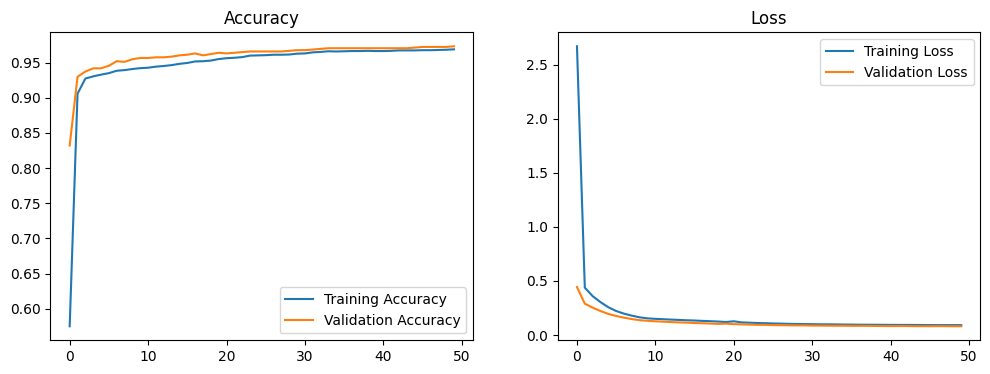

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# Import data
ann_train = pd.read_csv('/content/Loan_train.csv')
ann_test = pd.read_csv('/content/Loan_test.csv')

# Drop irrelevant columns
ann_train = ann_train.drop(columns=['ID', 'ZIPCode'])
ann_test = ann_test.drop(columns=['ID', 'ZIPCode'])

# Dummy code 'Education' attribute
ann_train = pd.get_dummies(ann_train, columns=['Education'], drop_first=True)
ann_test = pd.get_dummies(ann_test, columns=['Education'], drop_first=True)

# Define the target variable (y) and features (X)
X_train_ann = ann_train.drop(columns=['Personal_Loan'])
y_train_ann = ann_train['Personal_Loan']
X_test_ann = ann_test.drop(columns=['Personal_Loan'])
y_test_ann = ann_test['Personal_Loan']

# Normalize the continuous variables using StandardScaler
scaler = StandardScaler()
X_scaled_ann = scaler.fit_transform(X_train_ann)

# Set seed
tf.random.set_seed(3)

# Build the ANN model
model_ann = Sequential([
    Dense(11, activation='relu', input_shape=(X_train_ann.shape[1],)),  # Input layer with 11 nodes
    Dense(6, activation='relu'),  # Hidden layer with 6 nodes (adjustable to 12 if needed)
    Dense(1, activation='sigmoid')  # Output layer with 1 node for binary classification
])

# Compile the model
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model_ann.fit(X_train_ann, y_train_ann, validation_data=(X_test_ann, y_test_ann), epochs=50, batch_size=32, verbose=1)

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

# Show charts
plt.show()

In [ ]:
# Apply the ANN Model to testing data set
X_test_scaled_ann = scaler.transform(X_test_ann)
y_pred_ann = model_ann.predict(X_test_scaled_ann)
y_pred_binary_ann = (y_pred_ann > 0.5).astype(int)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_ann, y_pred_binary_ann))
print()
print("Classification Report:\n")
print(classification_report(y_test_ann, y_pred_binary_ann))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:

[[1030    0]
 [  54    0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1030
           1       0.00      0.00      0.00        54

    accuracy                           0.95      1084
   macro avg       0.48      0.50      0.49      1084
weighted avg       0.90      0.95      0.93      1084



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### **Decision Tree Model**

**Model Specification**

The Decision Tree model was optimized, using prepruning, to enhance interpretability and prevent overfitting. The following input parameters were specified:

* The tree depth was limited to $5$ levels.
* The minimum samples required to split was set to $10$.
* The minimum samples needed at each leaf nodes was set to $5$.
* The maximum quantity of leaf nodes was set at $20$.

**Results and Tree Model**

The model's initial split occurs based on income, with a threshold of $131,000$. If a customer meets this threshold, their credit card spending (at or above $2,950$/month) is evaluated, followed by additional conditions. The most influential features, according to the feature importance plot, are *Income* and *Education*, which align with crucial indicators of repayment ability and financial literacy.

**Model Accuracy**

Also, with a 99% accuracy score, this model demonstrates strong predictive power. AllLife Bank can effectively use these insights to target high-income earners, significant credit card spenders, and those with advanced education for future personal loan campaigns.

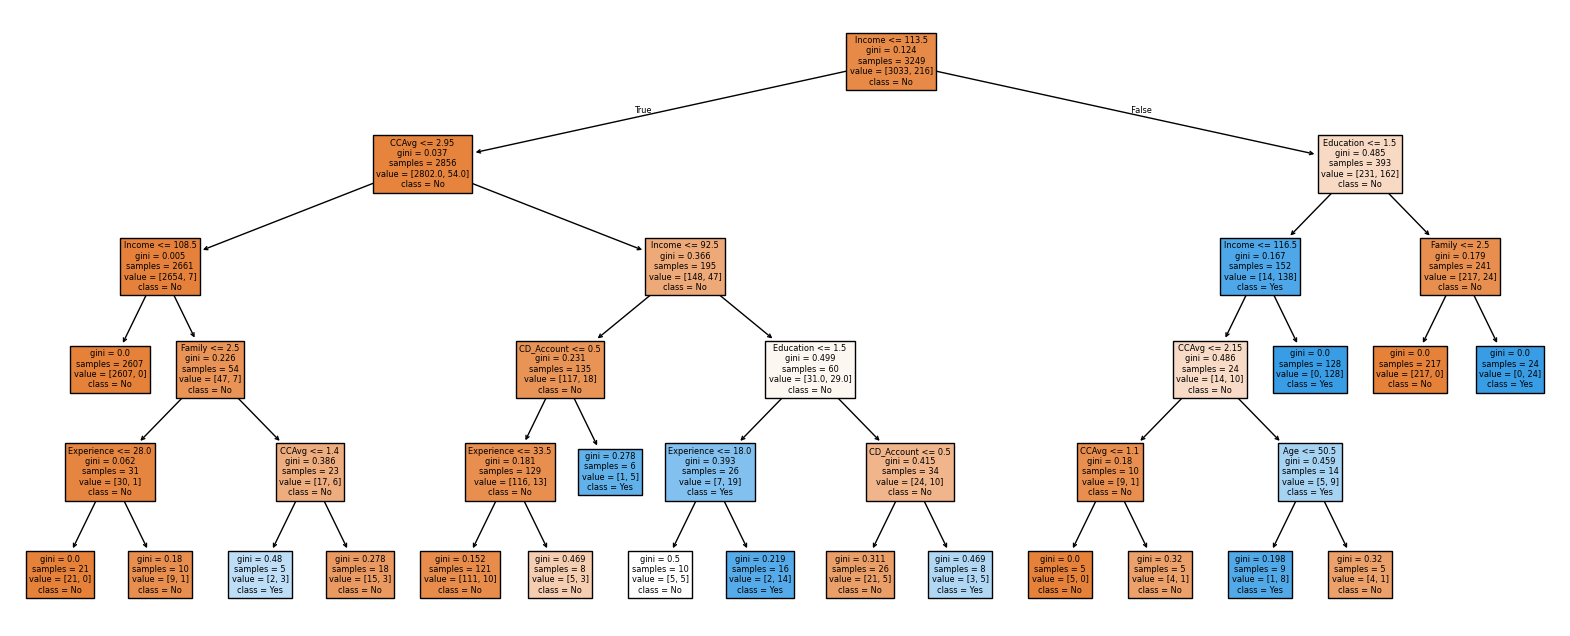

In [ ]:
# Import necessary libraries for decision tree modeling
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import plot_tree

# Import training and testing data
train_tree = pd.read_csv('/content/Loan_train.csv')
test_tree = pd.read_csv('/content/Loan_test.csv')

# Convert 'Education' into numerical form
label_encoder = LabelEncoder()
train_tree['Education'] = label_encoder.fit_transform(train_tree['Education'])
test_tree['Education'] = label_encoder.transform(test_tree['Education'])

# Drop unnecessary columns
train_tree = train_tree.drop(columns=['ID', 'ZIPCode'])
test_tree = test_tree.drop(columns=['ID', 'ZIPCode'])

# Define features
X_train_tree = train_tree.drop(columns=['Personal_Loan'])
y_train_tree = train_tree['Personal_Loan']
X_test_tree = test_tree.drop(columns=['Personal_Loan'])
y_test_tree = test_tree['Personal_Loan']

# Define the decision tree model with prepruning parameters
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,              # Limit tree depth to prevent overfitting
    min_samples_split=10,     # Minimum samples required to split a node
    min_samples_leaf=5,       # Minimum samples required at each leaf
    max_leaf_nodes=20         # Limit the maximum number of leaf nodes
)

# Fit the model
decision_tree.fit(X_train_tree, y_train_tree)

# Plot the decision tree
plt.figure(figsize=(20, 8))
plot_tree(decision_tree, filled=True, feature_names=X_train_tree.columns, class_names=['No', 'Yes'])
plt.show()

In [ ]:
# Create predictions
y_pred_tree = decision_tree.predict(X_test_tree)

# Evaluate model accuracy using test data and created predictions
val_accuracy_tree = accuracy_score(y_test_tree, y_pred_tree)
val_report_tree = classification_report(y_test_tree, y_pred_tree)

# Confusion matrix
conf_matrix_tree = confusion_matrix(y_test_tree, y_pred_tree)
print("Confusion Matrix:\n")
print(conf_matrix_tree)
print()

# Print accuracy scores and classification report
print("\nClassification Report:\n")
print(val_report_tree)

Confusion Matrix:

[[1025    5]
 [  11   43]]


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1030
           1       0.90      0.80      0.84        54

    accuracy                           0.99      1084
   macro avg       0.94      0.90      0.92      1084
weighted avg       0.98      0.99      0.98      1084



Decision Tree Feature Importance:

               Feature  Importance
2               Income    0.384301
5            Education    0.369321
3               Family    0.129271
4                CCAvg    0.074661
8           CD_Account    0.024475
1           Experience    0.009127
0                  Age    0.008843
6             Mortgage    0.000000
7   Securities_Account    0.000000
9               Online    0.000000
10          CreditCard    0.000000


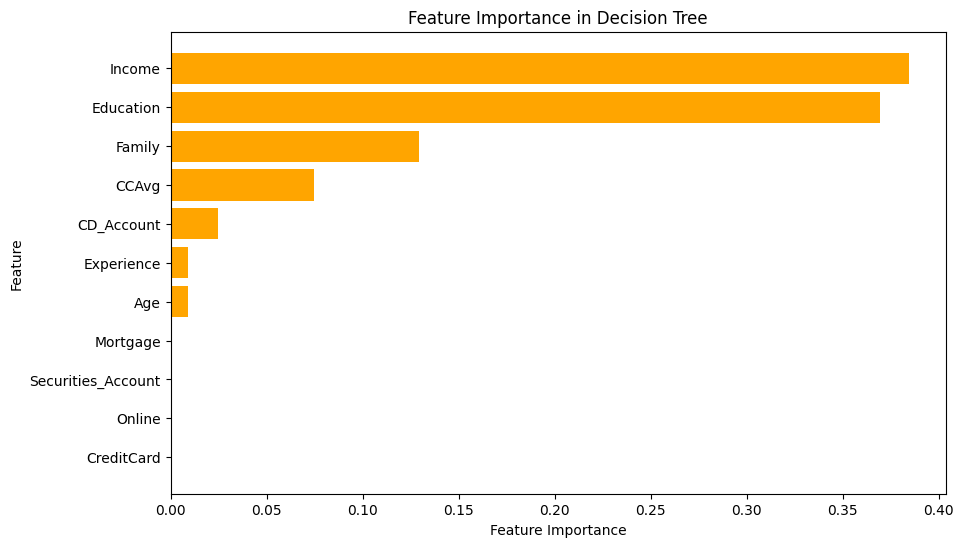

In [ ]:
# Extract feature importance
feature_importances_tree = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': decision_tree.feature_importances_
})

# Sort features by importance
feature_importances_tree = feature_importances_tree.sort_values(by='Importance', ascending=False)

# Display feature importance
print("Decision Tree Feature Importance:\n")
print(feature_importances_tree)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_tree['Feature'], feature_importances_tree['Importance'], color='orange')
plt.gca().invert_yaxis()  # Reverse order for better readability
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Decision Tree')
plt.show()

### **Conclusion and Business Recommendations**

The Decision Tree model is the most accurate predictive model for personal loan acceptance (99% accuracy), followed by Logistic Regression (98%) and the Artificial Neural Network (95%). The Decision Tree provides clear, actionable insights by segmenting customers based on factors like income (threshold: $113,500$) and credit card spending (at or above $2,950$/month), making it ideal for targeted marketing. Logistic Regression, on the other hand, highlights the significant impact of having a Certificate of Deposit (CD) account, along with income and education, on loan acceptance odds. To increase the bank's asset holdings through provisions of customer loans, the bank should:

* Focus on depositors earning over $113,500$ with high credit card spending and prioritize those holding CD accounts.
* Use segmentation from the Decision Tree to design personalized campaigns for high-income, high-spending customers.
* Combine model insights to create tailored offers that appeal to financial behaviors (ex: liquidity, income stability).
* Use Logistic Regression findings to strengthen marketing to educated depositors and CD account holders, ensuring alignment with customer needs and liquidity profiles.